In [8]:
# Global imports and configuration for Hanoi intersection analysis
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt
import json
from shapely.geometry import Polygon
from shapely.ops import unary_union

# Global grid parameters (matching map.ipynb)
LAT_START, LON_START = 20.027350, 104.790862
ROWS, COLS = 79, 127
CELL_STEP = 0.02780

# Global paths and settings
GEOJSON_PATH = "resources/diaphantinh.geojson"

OUTPUT_JSON = "resources/vinhphuc-percentages-2.json"
TARGET_PROVINCE = "Vĩnh Phúc" # Bắc Ninh, Hải Dương, Hải Phòng, Hưng Yên, Quảng Ninh, Vĩnh Phúc
TARGET_PROVINCES = ["Hà Nội", "Vĩnh Phúc", "Bắc Ninh", "Hải Dương", "Hải Phòng", "Hưng Yên", "Quảng Ninh"]

print(f"Grid parameters: {ROWS}x{COLS}, step={CELL_STEP}")
print(f"Target province: {TARGET_PROVINCE}")

# Load and filter geospatial data
print(f"Loading geojson from: {GEOJSON_PATH}")
gdf = gpd.read_file(GEOJSON_PATH)

Grid parameters: 79x127, step=0.0278
Target province: Vĩnh Phúc
Loading geojson from: resources/diaphantinh.geojson


Found 1 geometries for Vĩnh Phúc

Geometry coordinates:


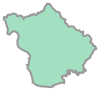

MultiPolygon 0.0: 651 points


In [9]:
hanoi = gdf[gdf["ten_tinh"] == TARGET_PROVINCE]

print(f"Found {len(hanoi)} geometries for {TARGET_PROVINCE}")

# Display geometry coordinates for inspection
print("\nGeometry coordinates:")
for i, geom in enumerate(hanoi.geometry):
    display(geom)
    if geom.geom_type == 'Polygon':
        print(f"Polygon {i}: {len(list(geom.exterior.coords))} points")
    elif geom.geom_type == 'MultiPolygon':
        for j, poly in enumerate(geom.geoms):
            print(f"MultiPolygon {i}.{j}: {len(list(poly.exterior.coords))} points")
    else:
        print(f"Unsupported geometry type: {geom.geom_type}")

In [10]:
# Grid creation and intersection analysis functions
def create_grid():
    """Create grid using global parameters"""
    lats = LAT_START + np.arange(ROWS) * CELL_STEP
    lons = LON_START + np.arange(COLS) * CELL_STEP
    grid = np.array([[(lat, lon) for lon in lons] for lat in lats])
    return grid

def calculate_intersection_percentage(geometries, grid):
    """Calculate intersection percentage between geometries and grid cells"""
    rows, cols = grid.shape[:2]
    result = np.zeros((rows, cols), dtype=float)

    # Union all geometries to avoid overlaps
    geometry_union = unary_union(list(geometries))

    for i in range(rows):
        for j in range(cols):
            lat, lon = grid[i, j]

            # Create cell polygon (Shapely uses lon, lat = x, y)
            cell_poly = Polygon([
                (lon, lat),
                (lon + CELL_STEP, lat),
                (lon + CELL_STEP, lat + CELL_STEP),
                (lon, lat + CELL_STEP)
            ])

            # Calculate intersection
            intersection = geometry_union.intersection(cell_poly)
            if not intersection.is_empty:
                result[i, j] = (intersection.area / cell_poly.area) * 100.0

    return result

# Create grid and calculate intersections
print("Creating grid...")
grid = create_grid()
print(f"Grid shape: {grid.shape}")

print("Calculating intersection percentages...")
percentages = calculate_intersection_percentage(hanoi.geometry, grid)
print(f"Non-zero intersections: {np.count_nonzero(percentages)}")
print(f"Max percentage: {percentages.max():.2f}%")

Creating grid...
Grid shape: (79, 127, 2)
Calculating intersection percentages...


Non-zero intersections: 172
Max percentage: 100.00%


In [11]:
percentagesAll = None

for province in TARGET_PROVINCES:
    hanoi = gdf[gdf["ten_tinh"] == province]

    print(f"Found {len(hanoi)} geometries for {province}")

    # Display geometry coordinates for inspection
    print("\nGeometry coordinates:")
    for i, geom in enumerate(hanoi.geometry):
        if geom.geom_type == 'Polygon':
            print(f"Polygon {i}: {len(list(geom.exterior.coords))} points")
        elif geom.geom_type == 'MultiPolygon':
            for j, poly in enumerate(geom.geoms):
                print(f"MultiPolygon {i}.{j}: {len(list(poly.exterior.coords))} points")
        else:
            print(f"Unsupported geometry type: {geom.geom_type}")

    # Create grid and calculate intersections
    print("Creating grid...")
    grid = create_grid()
    print(f"Grid shape: {grid.shape}")

    print("Calculating intersection percentages...")
    percentages = calculate_intersection_percentage(hanoi.geometry, grid)
    print(f"Non-zero intersections: {np.count_nonzero(percentages)}")
    print(f"Max percentage: {percentages.max():.2f}%")
    
    if percentagesAll is None:
        percentagesAll = percentages
    else:
        percentagesAll += percentages

# Export results
# export_data = export_to_json(percentagesAll)
# print(f"Summary: {len(export_data)} cells with intersections")

Found 1 geometries for Hà Nội

Geometry coordinates:
MultiPolygon 0.0: 1226 points
Creating grid...
Grid shape: (79, 127, 2)
Calculating intersection percentages...
Non-zero intersections: 456
Max percentage: 100.00%
Found 1 geometries for Vĩnh Phúc

Geometry coordinates:
MultiPolygon 0.0: 651 points
Creating grid...
Grid shape: (79, 127, 2)
Calculating intersection percentages...
Non-zero intersections: 172
Max percentage: 100.00%
Found 1 geometries for Bắc Ninh

Geometry coordinates:
MultiPolygon 0.0: 489 points
Creating grid...
Grid shape: (79, 127, 2)
Calculating intersection percentages...
Non-zero intersections: 124
Max percentage: 100.00%
Found 1 geometries for Hải Dương

Geometry coordinates:
MultiPolygon 0.0: 935 points
Creating grid...
Grid shape: (79, 127, 2)
Calculating intersection percentages...
Non-zero intersections: 239
Max percentage: 100.00%
Found 1 geometries for Hải Phòng

Geometry coordinates:
MultiPolygon 0.0: 15 points
MultiPolygon 0.1: 15 points
MultiPolygon 0.

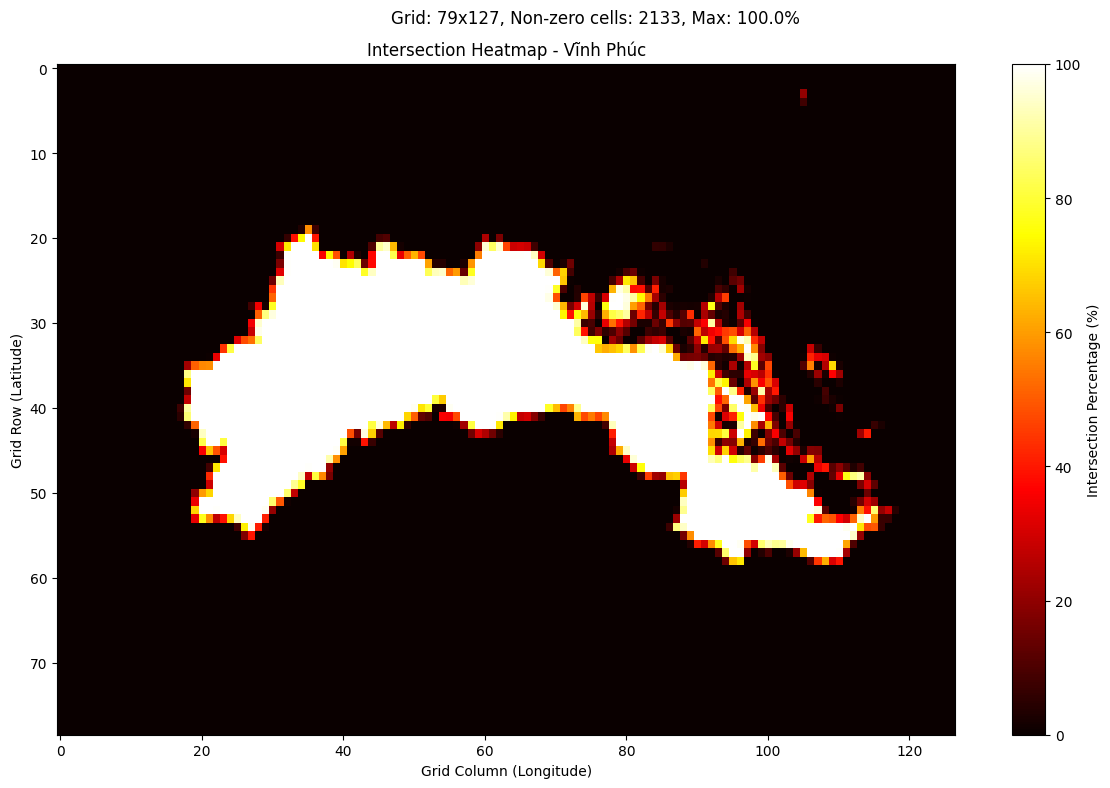

In [12]:
# Visualization
def plot_heatmap(data, title="Intersection Heatmap"):
    """Plot heatmap of intersection percentages"""
    plt.figure(figsize=(12, 8))
    im = plt.imshow(data, cmap='hot', interpolation='nearest', aspect='auto')
    plt.colorbar(im, label='Intersection Percentage (%)')
    plt.title(f'{title} - {TARGET_PROVINCE}')
    plt.xlabel('Grid Column (Longitude)')
    plt.ylabel('Grid Row (Latitude)')

    # Add statistics to title
    nonzero_count = np.count_nonzero(data)
    max_val = data.max()
    plt.suptitle(f'Grid: {ROWS}x{COLS}, Non-zero cells: {nonzero_count}, Max: {max_val:.1f}%')

    plt.tight_layout()
    plt.show()

# Plot the results
plot_heatmap(percentagesAll)

In [13]:
def export_to_json(data, filename=OUTPUT_JSON, min_percentage=0.0):
    """Export intersection data to JSON format (no metadata)"""
    results = []
    for i in range(data.shape[0]):
        for j in range(data.shape[1]):
            if data[i, j] > min_percentage:
                lat, lon = grid[i, j]
                results.append({
                    "row": int(i),
                    "col": int(j),
                    "lat": float(lat),
                    "lon": float(lon),
                    "percentage": float(data[i, j])
                })
    with open(filename, "w", encoding="utf-8") as f:
        json.dump(results, f, ensure_ascii=False, indent=2)
    print(f"Exported {len(results)} intersecting cells to {filename}")
    return results

# Export results
export_data = export_to_json(percentages)
print(f"Summary: {len(export_data)} cells with intersections")


Exported 972 intersecting cells to resources/vinhphuc-percentages-2.json
Summary: 972 cells with intersections
